## Image registration

The notebook uses a python package itk-elastix (https://proceedings.scipy.org/articles/gerudo-f2bc6f59-00d), scanpy, spatialdata (https://spatialdata.scverse.org/en/stable/) to demonstrate image registration in a few image examples. 

Source of the images:

* Fluorescence images - Broad Bioimage Benchmark Collection (https://bbbc.broadinstitute.org/) (Gustafsdottir et al., 2013) (Ljosa V, Sokolnicki KL, Carpenter AE (2012). Annotated high-throughput microscopy image sets for validation. Nature Methods 9(7):637 / doi. PMID: 22743765 PMCID: PMC3627348. Available at http://dx.doi.org/10.1038/nmeth.2083)
* Phase contrast images from Bhuvanasundar Renganathgan, Northwestern University, Chicago
* Multimodal data and images - 
  * Mass Sprectrometry imaging and Visium data from Vicari, M., Mirzazadeh, R., Nilsson, A. et al. Spatial multimodal analysis of transcriptomes and metabolomes in tissues. Nat Biotechnol 42, 1046–1050 (2024). https://doi.org/10.1038/s41587-023-01937-y (CC BY)
  * Xenium data is from https://github.com/giovp/spatialdata-sandbox/blob/main/xenium_2.0.0_io/download.py provided by SpatialData. 

In [1]:
# Importing packages 
import itk
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Essential functions
# Normalize function
def norm(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

### Fluorescence images

### Reading the files

In [31]:
fixed_image = itk.imread(r"C:\Users\sugsi131\Documents\Webinar\ImagesForDemo\Image1_raw.tif", itk.F)
moving_image = itk.imread(r"C:\Users\sugsi131\Documents\Webinar\ImagesForDemo\Image2_raw_translated.tif", itk.F)

### Visualization

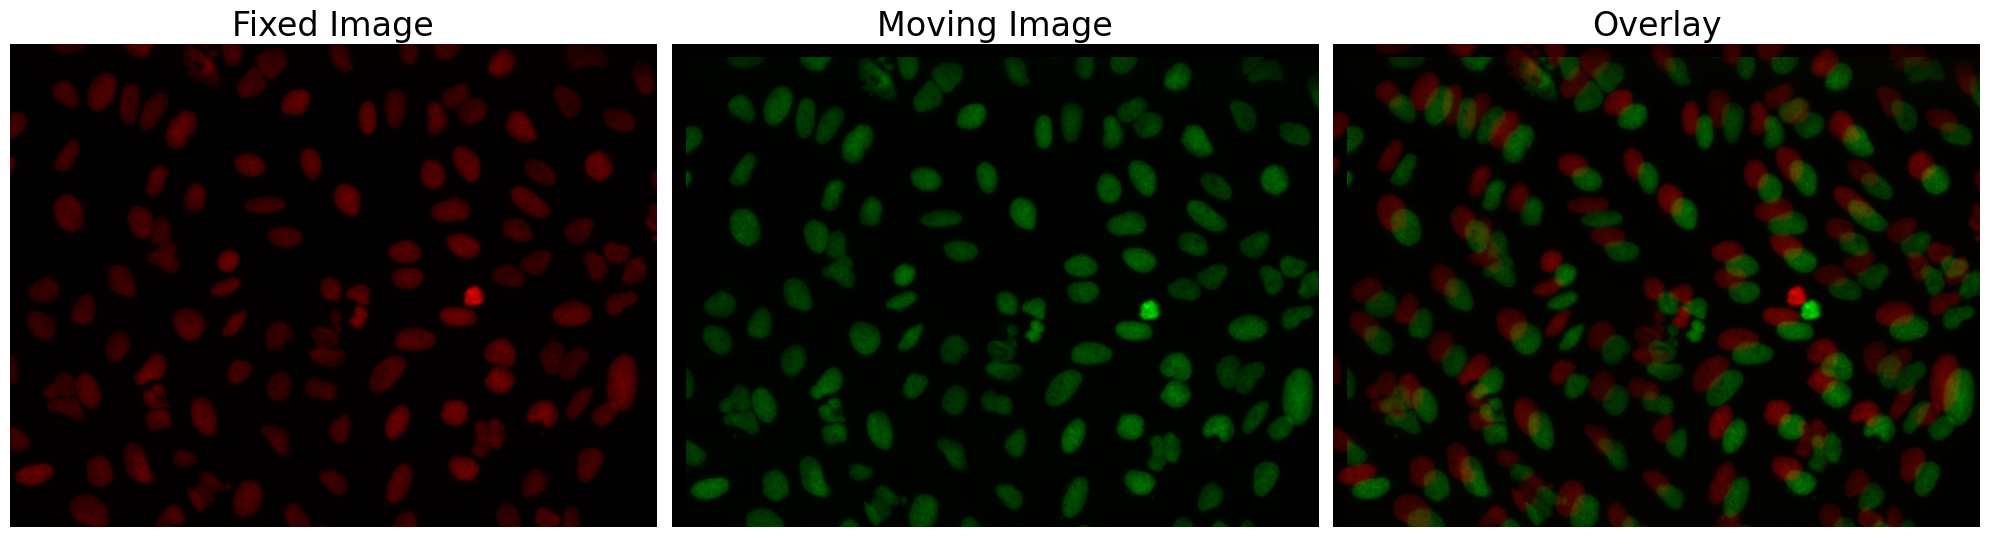

In [5]:
# Visualization
# Convert to array
fixed_arr = itk.GetArrayFromImage(fixed_image).astype(float)
moving_arr = itk.GetArrayFromImage(moving_image).astype(float)

fixed_slice = norm(fixed_arr)
moving_slice = norm(moving_arr)

fixed_color = np.zeros((fixed_slice.shape[0], fixed_slice.shape[1], 3))
fixed_color[:, :, 0] = fixed_slice    

moving_color = np.zeros((moving_slice.shape[0], moving_slice.shape[1], 3))
moving_color[:, :, 1] = moving_slice  

before_reg = np.zeros((fixed_slice.shape[0], fixed_slice.shape[1], 3))
before_reg[:, :, 0] = fixed_slice    
before_reg[:, :, 1] = moving_slice  

fig, axes = plt.subplots(1, 3, figsize=(20, 10))

axes[0].imshow(fixed_color)
axes[0].set_title('Fixed Image', fontsize=24)
axes[0].axis('off')

axes[1].imshow(moving_color)
axes[1].set_title('Moving Image', fontsize=24)
axes[1].axis('off')

axes[2].imshow(before_reg)
axes[2].set_title('Overlay', fontsize=24)
axes[2].axis('off')

plt.tight_layout()

### Registration 

In [32]:
default_rigid_parameter_map = itk.ParameterObject.GetDefaultParameterMap("rigid")
parameter_object = itk.ParameterObject.New(parameter_map=default_rigid_parameter_map)

In [33]:
# Call registration function
result_image, result_transform_parameters = itk.elastix_registration_method(
    fixed_image, moving_image, parameter_object=parameter_object, log_to_console=False
)

In [34]:
#Saving the registered image
itk.imwrite(result_image, r"C:\Users\sugsi131\Documents\Webinar\ImagesForDemo\Registered1.tif")

### Visualization

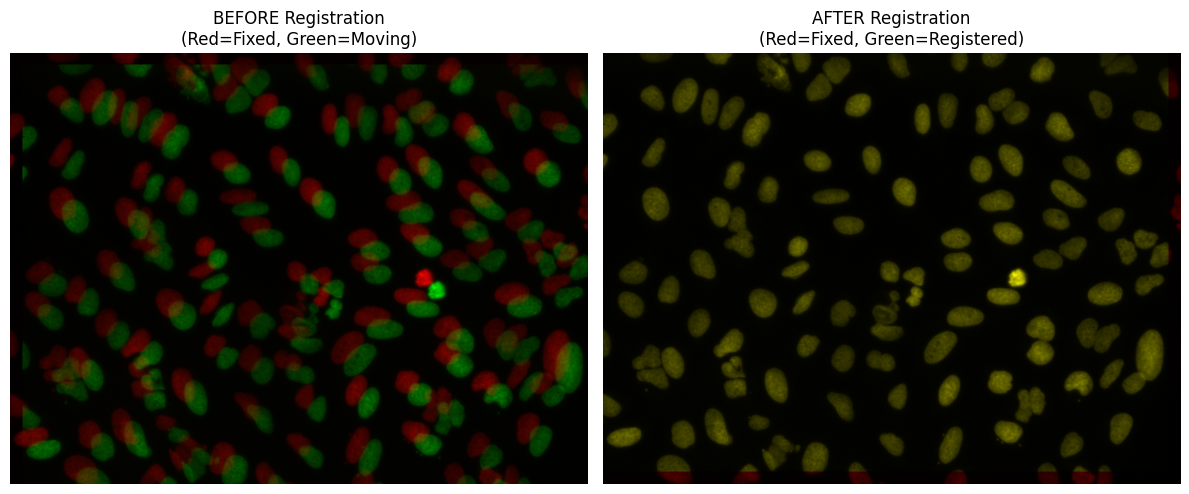

In [9]:
# Visualization
# Convert to array
fixed_arr = itk.GetArrayFromImage(fixed_image).astype(float)
moving_arr = itk.GetArrayFromImage(moving_image).astype(float)
registered_arr = itk.GetArrayFromImage(result_image).astype(float)


fixed_slice = norm(fixed_arr)
moving_slice = norm(moving_arr)
registered_slice = norm(registered_arr)

# Create BEFORE overlay (Fixed vs Moving)
overlay_before = np.zeros((fixed_slice.shape[0], fixed_slice.shape[1], 3))
overlay_before[:, :, 0] = fixed_slice    # Red = Fixed
overlay_before[:, :, 1] = moving_slice   # Green = Moving

# Create AFTER overlay (Fixed vs Registered)
overlay_after = np.zeros((fixed_slice.shape[0], fixed_slice.shape[1], 3))
overlay_after[:, :, 0] = fixed_slice       # Red = Fixed
overlay_after[:, :, 1] = registered_slice  # Green = Registered

# Display
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(overlay_before)
axes[0].set_title('BEFORE Registration\n(Red=Fixed, Green=Moving)')
axes[0].axis('off')

axes[1].imshow(overlay_after)
axes[1].set_title('AFTER Registration\n(Red=Fixed, Green=Registered)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

A default set of registration parameters are available for

* translation
* rigid
* affine
* bspline
* spline
* groupwise

### Understanding the parameters

In [10]:
# Get number of transforms (could be multiple for multi-resolution)
num_transforms = result_transform_parameters.GetNumberOfParameterMaps()
print(f"Number of parameter maps: {num_transforms}")

# Get the parameter map (usually index 0 for single transform)
param_map = result_transform_parameters.GetParameterMap(0)

# Print all parameters
print("All Parameters")
for key in param_map:
    print(f"{key}: {param_map[key]}")

Number of parameter maps: 1
All Parameters
CenterOfRotationPoint: ('347.5', '259.5')
CompressResultImage: ('false',)
DefaultPixelValue: ('0',)
Direction: ('1', '0', '0', '1')
FinalBSplineInterpolationOrder: ('3',)
FixedImageDimension: ('2',)
FixedInternalImagePixelType: ('float',)
HowToCombineTransforms: ('Compose',)
Index: ('0', '0')
InitialTransformParameterFileName: ('NoInitialTransform',)
MovingImageDimension: ('2',)
MovingInternalImagePixelType: ('float',)
NumberOfParameters: ('3',)
Origin: ('0', '0')
ResampleInterpolator: ('FinalBSplineInterpolator',)
Resampler: ('DefaultResampler',)
ResultImageFormat: ('nii',)
ResultImagePixelType: ('float32',)
Size: ('696', '520')
Spacing: ('1', '1')
Transform: ('EulerTransform',)
TransformParameters: ('0.00001217104995064151', '14.994626249479657', '14.984952837008262')
UseDirectionCosines: ('true',)


### Second example 

### Reading the images

In [11]:
fixed_image = itk.imread(r"C:\Users\sugsi131\Documents\Webinar\ImagesForDemo\Image1_raw.tif", itk.F)
moving_image_2 = itk.imread(r"C:\Users\sugsi131\Documents\Webinar\ImagesForDemo\Image2_raw_rotated.tif", itk.F)

### Visualization

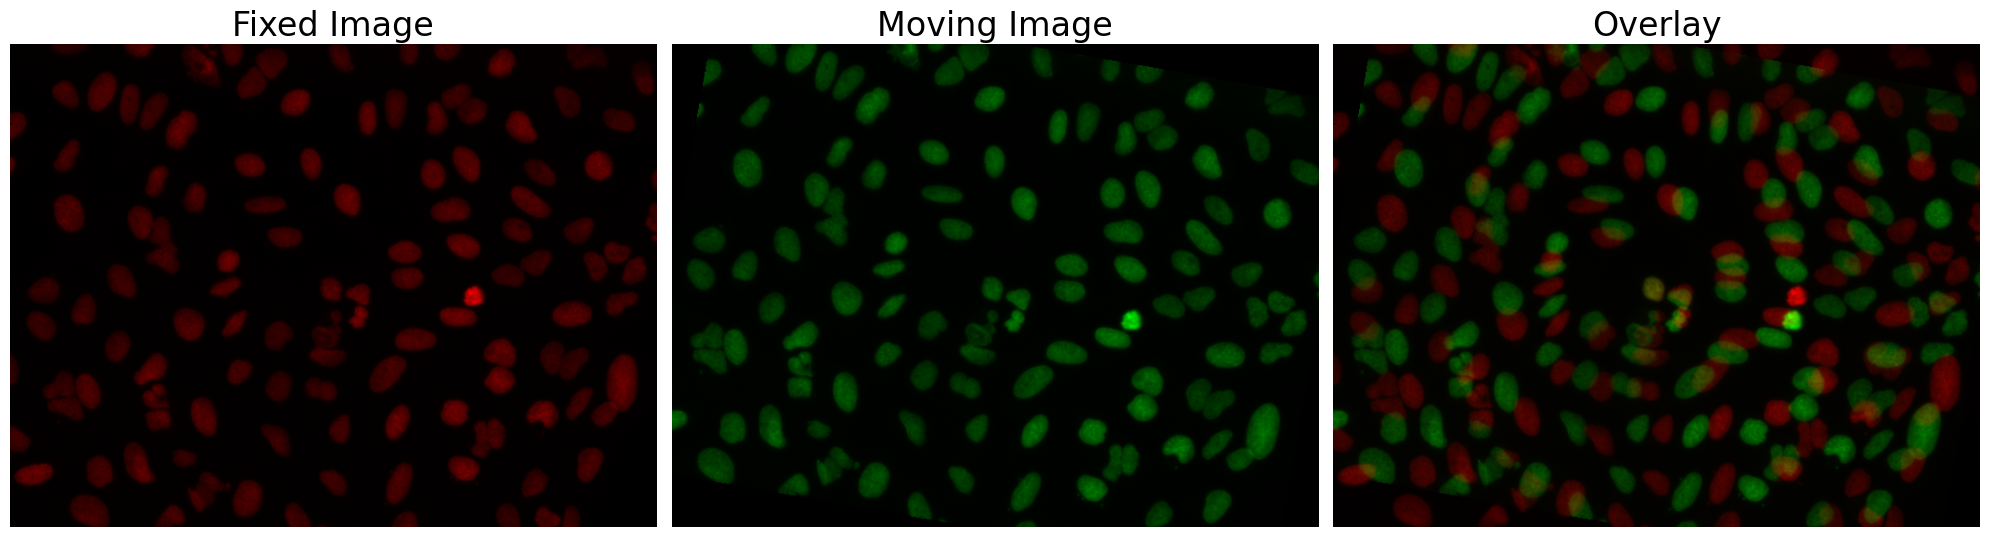

In [12]:
# Visualization
# Convert to array
fixed_arr = itk.GetArrayFromImage(fixed_image).astype(float)
moving_arr = itk.GetArrayFromImage(moving_image_2).astype(float)

fixed_slice = norm(fixed_arr)
moving_slice = norm(moving_arr)

fixed_color = np.zeros((fixed_slice.shape[0], fixed_slice.shape[1], 3))
fixed_color[:, :, 0] = fixed_slice    

moving_color = np.zeros((moving_slice.shape[0], moving_slice.shape[1], 3))
moving_color[:, :, 1] = moving_slice  

before_reg = np.zeros((fixed_slice.shape[0], fixed_slice.shape[1], 3))
before_reg[:, :, 0] = fixed_slice    
before_reg[:, :, 1] = moving_slice  

fig, axes = plt.subplots(1, 3, figsize=(20, 10))

axes[0].imshow(fixed_color)
axes[0].set_title('Fixed Image', fontsize=24)
axes[0].axis('off')

axes[1].imshow(moving_color)
axes[1].set_title('Moving Image', fontsize=24)
axes[1].axis('off')

axes[2].imshow(before_reg)
axes[2].set_title('Overlay', fontsize=24)
axes[2].axis('off')

plt.tight_layout()

### Registration

In [13]:
default_rigid_parameter_map = itk.ParameterObject.GetDefaultParameterMap("rigid")
parameter_object = itk.ParameterObject.New(parameter_map=default_rigid_parameter_map)

In [14]:
# Call registration function
result_image_2, result_transform_parameters_2 = itk.elastix_registration_method(
    fixed_image, moving_image_2, parameter_object=parameter_object, log_to_console=False
)

In [15]:
#Saving the image
itk.imwrite(result_image_2, r"C:\Users\sugsi131\Documents\Webinar\ImagesForDemo\Registered2.tif")

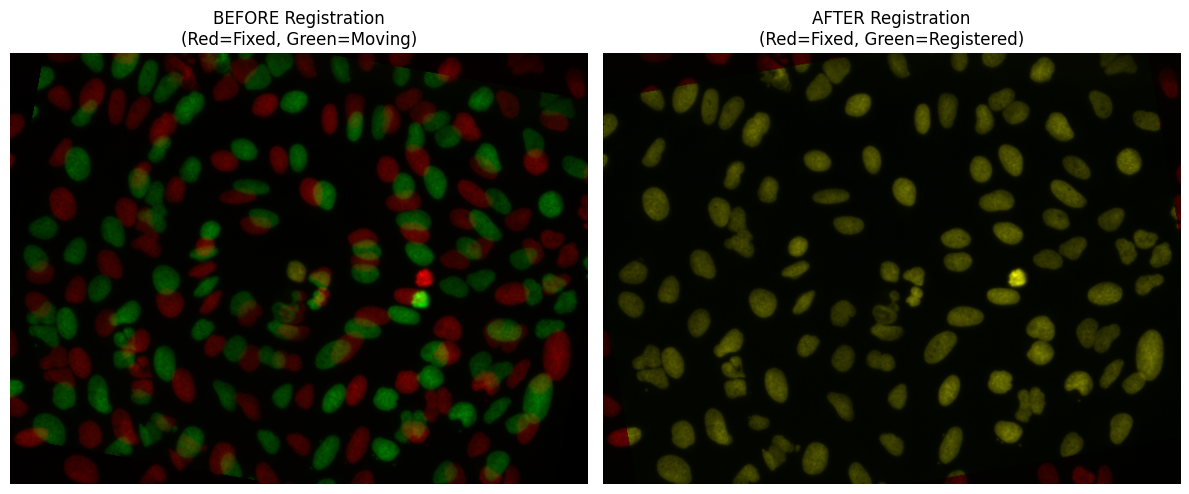

In [16]:
# Visualization
# Convert to array
fixed_arr = itk.GetArrayFromImage(fixed_image).astype(float)
moving_arr = itk.GetArrayFromImage(moving_image_2).astype(float)
registered_arr = itk.GetArrayFromImage(result_image_2).astype(float)


fixed_slice = norm(fixed_arr)
moving_slice = norm(moving_arr)
registered_slice = norm(registered_arr)

# Create BEFORE overlay (Fixed vs Moving)
overlay_before = np.zeros((fixed_slice.shape[0], fixed_slice.shape[1], 3))
overlay_before[:, :, 0] = fixed_slice    # Red = Fixed
overlay_before[:, :, 1] = moving_slice   # Green = Moving

# Create AFTER overlay (Fixed vs Registered)
overlay_after = np.zeros((fixed_slice.shape[0], fixed_slice.shape[1], 3))
overlay_after[:, :, 0] = fixed_slice       # Red = Fixed
overlay_after[:, :, 1] = registered_slice  # Green = Registered

# Display
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(overlay_before)
axes[0].set_title('BEFORE Registration\n(Red=Fixed, Green=Moving)')
axes[0].axis('off')

axes[1].imshow(overlay_after)
axes[1].set_title('AFTER Registration\n(Red=Fixed, Green=Registered)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [17]:
# Get number of transforms (could be multiple for multi-resolution)
num_transforms = result_transform_parameters_2.GetNumberOfParameterMaps()
print(f"Number of parameter maps: {num_transforms}")

# Get the parameter map (usually index 0 for single transform)
param_map = result_transform_parameters_2.GetParameterMap(0)

# Print all parameters
print("\n--- All Parameters ---")
for key in param_map:
    print(f"{key}: {param_map[key]}")

Number of parameter maps: 1

--- All Parameters ---
CenterOfRotationPoint: ('347.5', '259.5')
CompressResultImage: ('false',)
DefaultPixelValue: ('0',)
Direction: ('1', '0', '0', '1')
FinalBSplineInterpolationOrder: ('3',)
FixedImageDimension: ('2',)
FixedInternalImagePixelType: ('float',)
HowToCombineTransforms: ('Compose',)
Index: ('0', '0')
InitialTransformParameterFileName: ('NoInitialTransform',)
MovingImageDimension: ('2',)
MovingInternalImagePixelType: ('float',)
NumberOfParameters: ('3',)
Origin: ('0', '0')
ResampleInterpolator: ('FinalBSplineInterpolator',)
Resampler: ('DefaultResampler',)
ResultImageFormat: ('nii',)
ResultImagePixelType: ('float32',)
Size: ('696', '520')
Spacing: ('1', '1')
Transform: ('EulerTransform',)
TransformParameters: ('0.17455850168155004', '-0.002338185513119788', '-0.016232696985179963')
UseDirectionCosines: ('true',)


### Drifted images - Phase contrast

In [18]:
drifted_fixed_image = itk.imread(r"C:\Users\sugsi131\Documents\Webinar\ImagesForDemo\drift1.tif", itk.F)
drifted_moving_image = itk.imread(r"C:\Users\sugsi131\Documents\Webinar\ImagesForDemo\drift2.tif", itk.F)

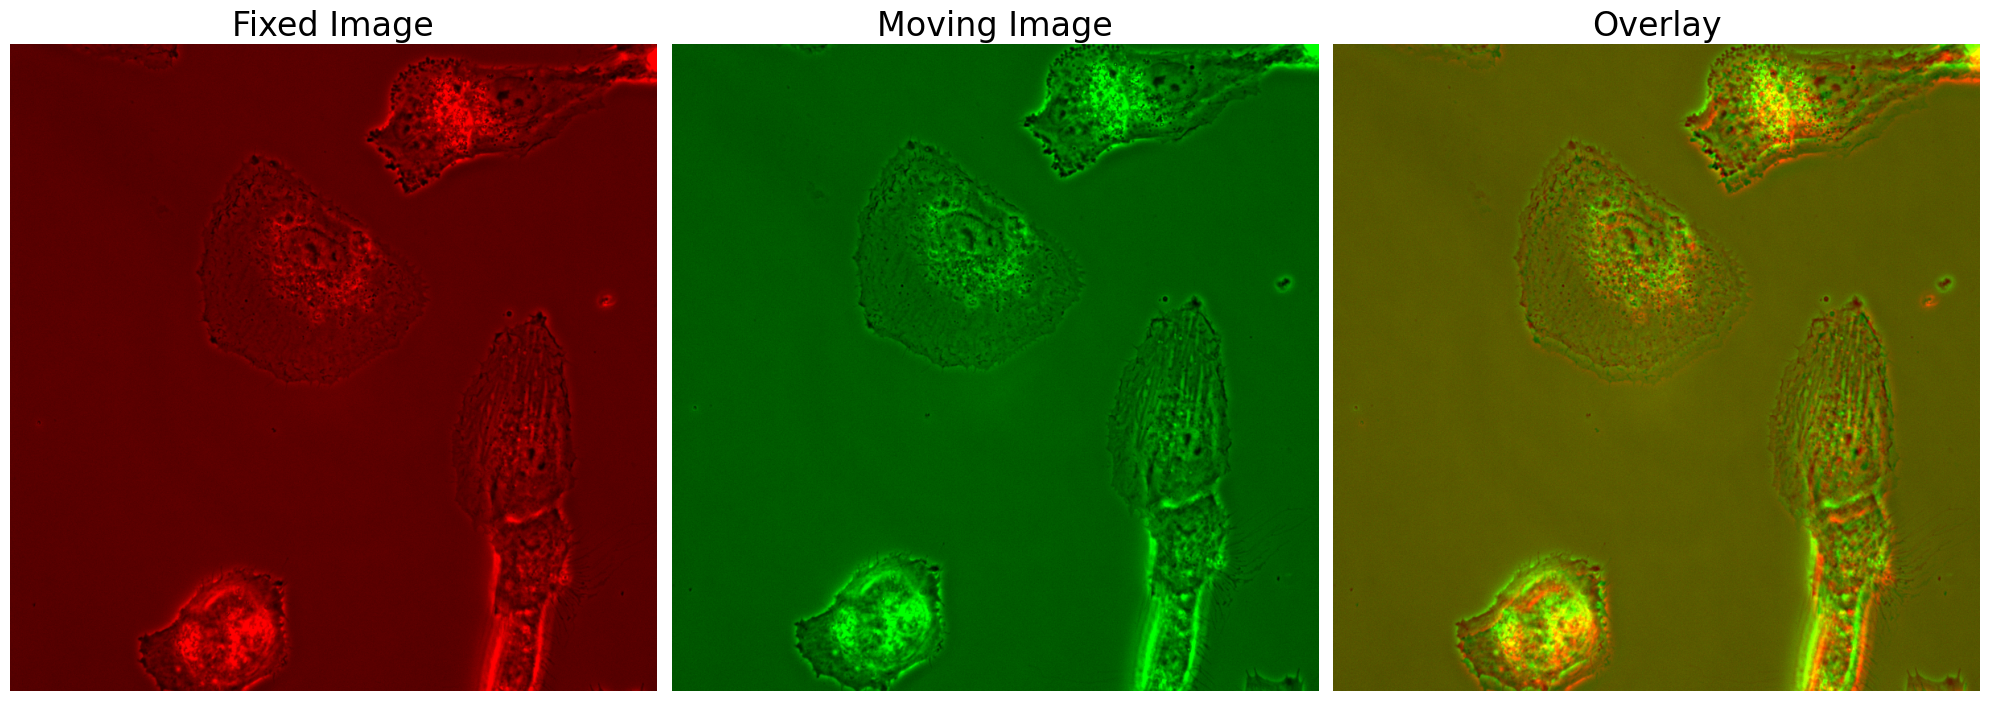

In [19]:
# Visualization
# Convert to array
fixed_arr = itk.GetArrayFromImage(drifted_fixed_image).astype(float)
moving_arr = itk.GetArrayFromImage(drifted_moving_image).astype(float)

fixed_slice = norm(fixed_arr)
moving_slice = norm(moving_arr)

fixed_color = np.zeros((fixed_slice.shape[0], fixed_slice.shape[1], 3))
fixed_color[:, :, 0] = fixed_slice    

moving_color = np.zeros((moving_slice.shape[0], moving_slice.shape[1], 3))
moving_color[:, :, 1] = moving_slice  

before_reg = np.zeros((fixed_slice.shape[0], fixed_slice.shape[1], 3))
before_reg[:, :, 0] = fixed_slice    
before_reg[:, :, 1] = moving_slice  

fig, axes = plt.subplots(1, 3, figsize=(20, 10))

axes[0].imshow(fixed_color)
axes[0].set_title('Fixed Image', fontsize=24)
axes[0].axis('off')

axes[1].imshow(moving_color)
axes[1].set_title('Moving Image', fontsize=24)
axes[1].axis('off')

axes[2].imshow(before_reg)
axes[2].set_title('Overlay', fontsize=24)
axes[2].axis('off')

plt.tight_layout()

### Registration 

In [20]:
default_rigid_parameter_map = itk.ParameterObject.GetDefaultParameterMap("rigid")
parameter_object = itk.ParameterObject.New(parameter_map=default_rigid_parameter_map)

In [21]:
# Call registration function
result_image_drifted, result_transform_parameters_drifted = itk.elastix_registration_method(
    drifted_fixed_image, drifted_moving_image, parameter_object=parameter_object, log_to_console=False
)

In [22]:
itk.imwrite(result_image, r"C:\Users\sugsi131\Documents\Webinar\ImagesForDemo\Registered_drift.tif")

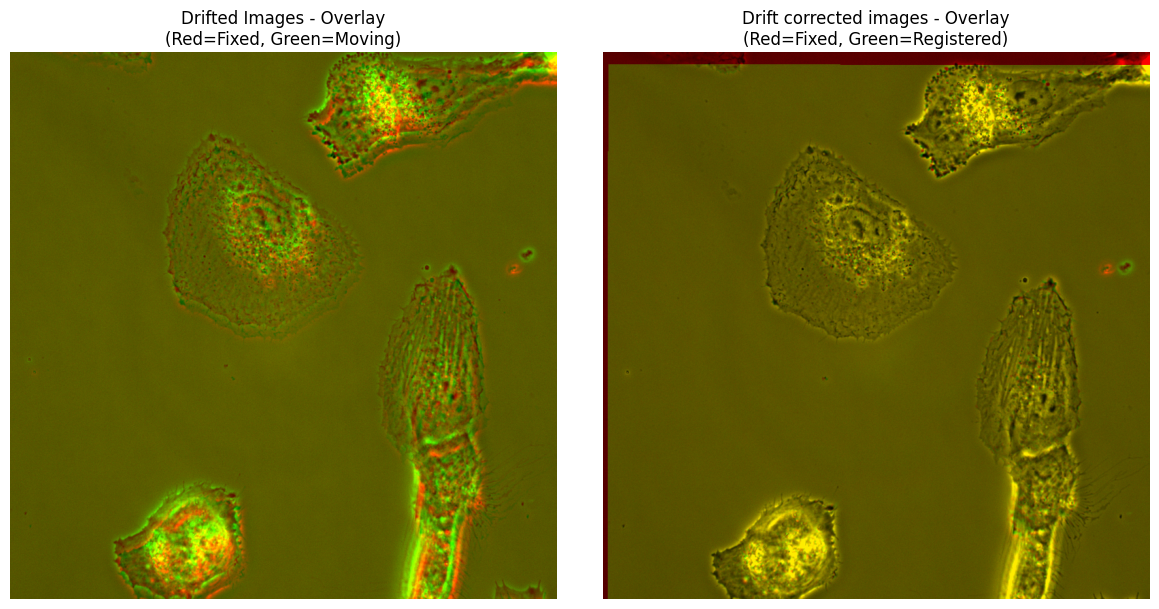

In [23]:
# Visualization
# Convert to array
fixed_arr = itk.GetArrayFromImage(drifted_fixed_image).astype(float)
moving_arr = itk.GetArrayFromImage(drifted_moving_image).astype(float)
registered_arr = itk.GetArrayFromImage(result_image_drifted).astype(float)


fixed_slice = norm(fixed_arr)
moving_slice = norm(moving_arr)
registered_slice = norm(registered_arr)

# Create BEFORE overlay (Fixed vs Moving)
overlay_before = np.zeros((fixed_slice.shape[0], fixed_slice.shape[1], 3))
overlay_before[:, :, 0] = fixed_slice    # Red = Fixed
overlay_before[:, :, 1] = moving_slice   # Green = Moving

# Create AFTER overlay (Fixed vs Registered)
overlay_after = np.zeros((fixed_slice.shape[0], fixed_slice.shape[1], 3))
overlay_after[:, :, 0] = fixed_slice       # Red = Fixed
overlay_after[:, :, 1] = registered_slice  # Green = Registered

# Display
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(overlay_before)
axes[0].set_title('Drifted Images - Overlay\n(Red=Fixed, Green=Moving)')
axes[0].axis('off')

axes[1].imshow(overlay_after)
axes[1].set_title('Drift corrected images - Overlay\n(Red=Fixed, Green=Registered)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [24]:
# Get number of transforms (could be multiple for multi-resolution)
num_transforms = result_transform_parameters_drifted.GetNumberOfParameterMaps()
print(f"Number of parameter maps: {num_transforms}")

# Get the parameter map (usually index 0 for single transform)
param_map = result_transform_parameters_drifted.GetParameterMap(0)

# Print all parameters
print("\n--- All Parameters ---")
for key in param_map:
    print(f"{key}: {param_map[key]}")

Number of parameter maps: 1

--- All Parameters ---
CenterOfRotationPoint: ('401.5', '401.5')
CompressResultImage: ('false',)
DefaultPixelValue: ('0',)
Direction: ('1', '0', '0', '1')
FinalBSplineInterpolationOrder: ('3',)
FixedImageDimension: ('2',)
FixedInternalImagePixelType: ('float',)
HowToCombineTransforms: ('Compose',)
Index: ('0', '0')
InitialTransformParameterFileName: ('NoInitialTransform',)
MovingImageDimension: ('2',)
MovingInternalImagePixelType: ('float',)
NumberOfParameters: ('3',)
Origin: ('0', '0')
ResampleInterpolator: ('FinalBSplineInterpolator',)
Resampler: ('DefaultResampler',)
ResultImageFormat: ('nii',)
ResultImagePixelType: ('float32',)
Size: ('804', '804')
Spacing: ('1', '1')
Transform: ('EulerTransform',)
TransformParameters: ('-0.00010408754966449988', '-7.473314693740544', '-18.505528153092555')
UseDirectionCosines: ('true',)


### Multimodal data

In [25]:
#Imports
import spatialdata as sd
import spatialdata_plot
from spatialdata_io import xenium
from spatialdata.models import Image2DModel
import tifffile
from spatialdata.transformations import get_transformation
from spatialdata import bounding_box_query, to_circles, to_polygons
import scanpy as sc
from spatialdata.transformations import ( Affine, MapAxis, Scale, Sequence, Translation, set_transformation, get_transformation)
from spatialdata import concatenate, get_extent
import pandas as pd

### Example 1 - Visium (gene expression) + mass spectrometry imaging (MSI) data + H&E image
### Reading the files

In [26]:
visium = sc.read_visium(r"C:\\Users\\sugsi131\\Documents\\Webinar\\ImagesForDemo\\documents-export-2026-3-24\\data\\V11L12-109_B1\\visium\\", library_id="rna")
msi = sc.read_visium(r"C:\\Users\\sugsi131\\Documents\\Webinar\\ImagesForDemo\\documents-export-2026-3-24\data\\V11L12-109_B1\\msi_aggregated\\", library_id="msi")
print(msi, visium)

Use `squidpy.read.visium` instead.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Use `squidpy.read.visium` instead.


AnnData object with n_obs × n_vars = 2394 × 1538
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial' AnnData object with n_obs × n_vars = 3120 × 32285
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'


### Overlaying mass spectrometry imaging data on the H&E image

Use `squidpy.pl.spatial_scatter` instead.


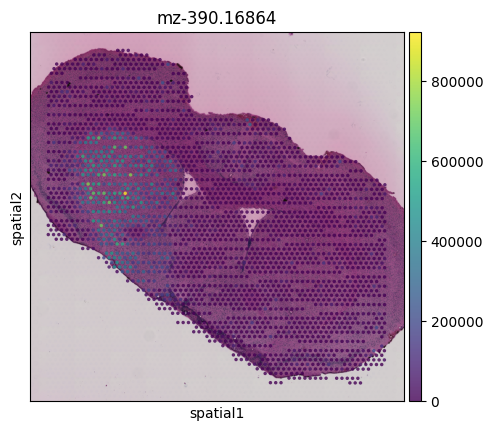

In [27]:
sc.pl.spatial(msi, img_key="hires", color="mz-390.16864",alpha=0.8)

### Example 2 - Xenium (gene expression) + H&E image


### Reading the Xenium files

In [28]:
xenium_path = r"C:\\Users\\sugsi131\\Documents\\Webinar\\ImagesForDemo\\Xenium_FFPE_Human_Breast_Cancer_Rep1_outs\\outs\\"

In [29]:
sd_xenium = xenium(
    path =xenium_path,
    cell_boundaries=True,
    nucleus_boundaries=True,
    morphology_focus=False, 
    cells_as_circles=True,
)

`cell_boundaries` is being deprecated as an argument to `xenium.xenium` in SpatialData version 0.1, switch to `cells_boundaries` instead.
Transforming to str index.


WARNING  The `feature_key` column feature_name is categorical with unknown categories. Please ensure the categories
         are known before calling `PointsModel.parse()` to avoid significant performance implications due to the   
         need for dask to compute the categories. If you did not use PointsModel.parse() explicitly in your code   
         (e.g. this message is coming from a reader in `spatialdata_io`), please report this finding.              


In [30]:
sd_xenium

SpatialData object
├── Images
│     └── 'morphology_mip': DataTree[cyx] (1, 25778, 35416), (1, 12889, 17708), (1, 6444, 8854), (1, 3222, 4427), (1, 1611, 2213)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (25778, 35416), (12889, 17708), (6444, 8854), (3222, 4427), (1611, 2213)
│     └── 'nucleus_labels': DataTree[yx] (25778, 35416), (12889, 17708), (6444, 8854), (3222, 4427), (1611, 2213)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 8) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (167780, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (167780, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (167780, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (167780, 313)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_mip (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), cell_circles (Shapes), nucleus_boundaries (Shapes)

### Reading the H&E image

In [25]:
# Read H&E image
he_image = tifffile.imread(r"C:\Users\sugsi131\Documents\Webinar\ImagesForDemo\documents-export-2026-3-24\data\xenium\Xenium_V1_humanLung_Cancer_FFPE_he_image.ome.tif")

# Create SpatialData image
he_sdata = Image2DModel.parse(
    he_image,
    dims=("c", "y", "x"),  # Adjust based on your image dimensions
)


(<Figure size 988.8x604.8 with 1 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x15c5db21950>)

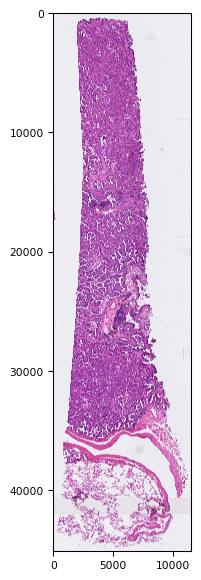

In [38]:
tifffile.imshow(he_image)

### Reading the transformation matrix

In [45]:
matrix_df = pd.read_csv(r"C:\Users\sugsi131\Documents\Webinar\ImagesForDemo\documents-export-2026-3-24\data\xenium\Xenium_V1_humanLung_Cancer_FFPE_he_imagealignment.csv", header=None)

In [59]:
reg = Affine(
    matrix_df.to_numpy(),
    input_axes=("x", "y"),
    output_axes=("x", "y"),
).inverse()


### Applying the transformation to the spatialdata object


In [60]:
# Apply to H&E image
set_transformation(
    sd_xenium.images["he_image"],
    transformation=reg,
    to_coordinate_system="global"
)


In [61]:
sd_xenium

SpatialData object
├── Images
│     ├── 'he_image': DataArray[cyx] (3, 45087, 11580)
│     └── 'morphology_mip': DataTree[cyx] (1, 25778, 35416), (1, 12889, 17708), (1, 6444, 8854), (1, 3222, 4427), (1, 1611, 2213)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (25778, 35416), (12889, 17708), (6444, 8854), (3222, 4427), (1611, 2213)
│     └── 'nucleus_labels': DataTree[yx] (25778, 35416), (12889, 17708), (6444, 8854), (3222, 4427), (1611, 2213)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 8) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (167780, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (167780, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (167780, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (167780, 313)
with coordinate systems:
    ▸ 'global', with elements:
        he_image (Images), morphology_mip (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_

### Visualization

The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.011904762..1.0].
The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.


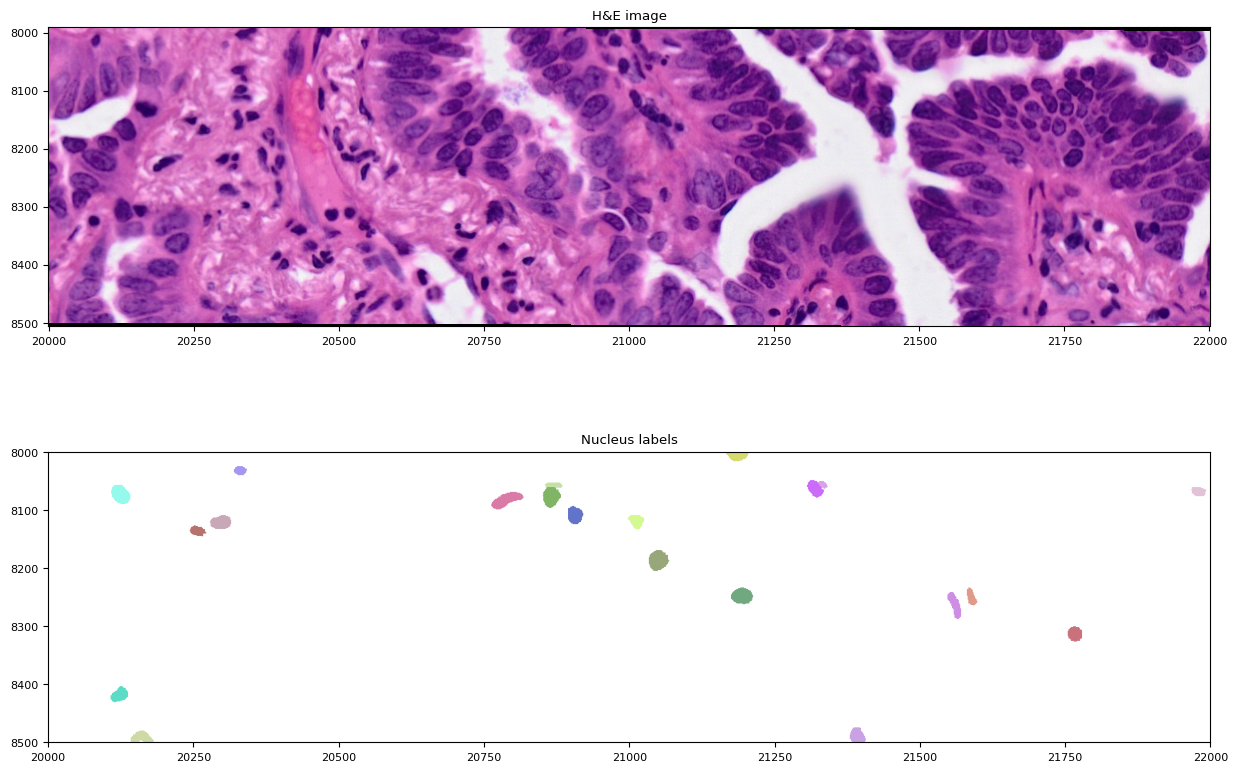

In [51]:
axes = plt.subplots(2, 1, figsize=(15, 10))[1].flatten()

def crop0(x):
    return bounding_box_query(
        x,
        min_coordinate=[20_000, 8000],
        max_coordinate=[22_000, 8500],
        axes=("x", "y"),
        target_coordinate_system="global",
    )


crop0(sd_xenium).pl.render_images("he_image").pl.show(ax=axes[0], title="H&E image", coordinate_systems="global")
crop0(sd_xenium).pl.render_labels("nucleus_labels").pl.show(ax=axes[1], title="Nucleus labels", coordinate_systems="global")